# **Deep Leakage from Gradients (DLG)**

# 1. Core Problem & Contribution

**The Assumption:**  
It was widely believed that gradients computed by a network by processing an input were a safe information to share as it did not expose the raw training data.

**The Discovery:**  
Researchers have found that this assumption is dangerously wrong. The research community has demonstrated that it is possible to **reconstruct the private training data (both inputs and labels)** using only the gradients produced by a network.

**Key Differentiator:**  
Earlier attacks were relatively *shallow*—they could infer high-level properties (for example, whether a batch contained a face) or generate synthetic samples with similar characteristics.  
**DLG**, in contrast, achieves **pixel-wise and token-wise accurate reconstruction** of the exact original data samples.

# 2. Mathematical Formulation & Method

The attack is formulated as an **optimization problem**.

---

## Setup

- A model with weights `W` and loss function `ℓ`
- A victim holds private data: a batch of inputs `x` and labels `y`
- The victim computes gradients using standard backpropagation:

Gradient w.r.t. weights:

∇W = ∂ℓ(F(x, W), y) / ∂W

These gradients are then shared with a potential adversary.

---

## Attacker’s Knowledge and Goal

The attacker knows:
- The model architecture `F`
- The current model weights `W`
- The shared gradients `∇W`

**Goal:** Recover the original private data `(x, y)`.

---

## The DLG Algorithm

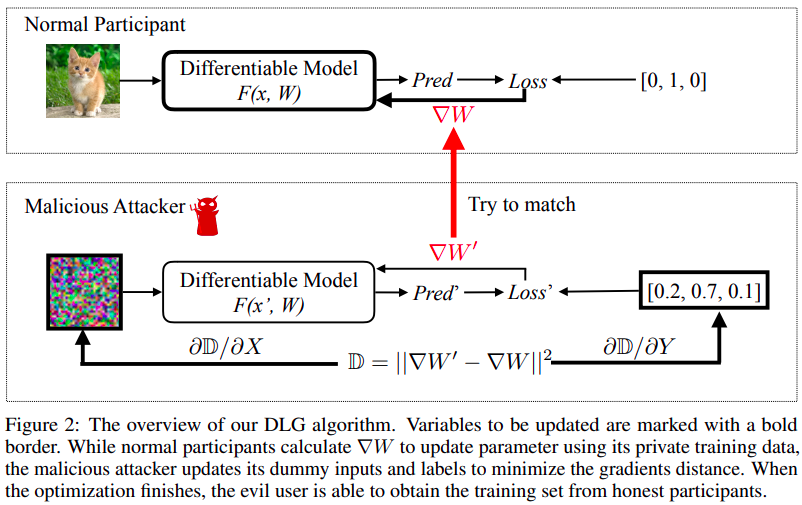

The key insight of DLG is that **gradients are a deterministic function of the data**.  
Therefore, if two datasets produce the same gradients, they must be the same (or extremely close).

---

### 1. Initialize Dummy Data

Randomly initialize:
- Dummy inputs `x'`
- Dummy labels `y'`

---

### 2. Compute Dummy Gradients

Feed the dummy data through the same model to compute gradients:

∇W' = ∂ℓ(F(x', W), y') / ∂W

---

### 3. Define the Optimization Objective

Define the loss as the distance between real gradients and dummy gradients, typically using L2 distance:

L = || ∇W' − ∇W ||²  
  = || ∂ℓ(F(x', W), y') / ∂W − ∇W ||²

---

### 4. Optimize Dummy Inputs and Labels

- The model weights `W` are kept **fixed**
- The attacker treats `x'` and `y'` as **optimizable parameters**
- Gradient-based optimizers such as **L-BFGS** are used to minimize `L`

Optimization objective:

(x'*, y'*) = argmin over (x', y') of || ∇W' − ∇W ||²

---

### 5. Recover the Private Data

As optimization progresses:

L → 0  ⇒  ∇W' ≈ ∇W

The paper empirically shows that this forces:

x' ≈ x  
y' ≈ y  

resulting in **near-exact reconstruction** of the original private data.

---

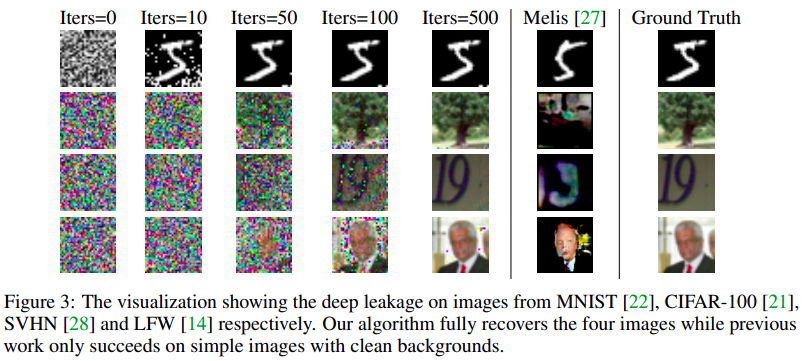

## Mathematical Nuance

This optimization requires **second-order derivatives**.

To compute gradients of the loss `L` with respect to `x'` and `y'`, the attacker must differentiate *through the gradient computation itself*.

Modern auto-differentiation frameworks (such as **PyTorch**, used in the paper) support **higher-order gradients**, making this attack computationally feasible.

# 3. Imports and Setup

We begin by importing the necessary libraries for deep learning, computer vision, data loading, and visualization.

**Key libraries used:**

- **PyTorch:** Building and training neural networks  
- **TorchVision:** Loading standard vision datasets such as MNIST  
- **Matplotlib:** Visualizing results and model behavior  


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader

In [ ]:
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# 4. Neural Network Definition (LeNet)

**Architecture:**  
A simple convolutional neural network with **two convolutional layers** followed by **two fully connected layers**.

**Key features:**

- Uses **sigmoid activations**, as mentioned in the DLG paper, to improve gradient behavior during reconstruction  
- Specifically designed for **MNIST** (28×28 grayscale images)  
- Produces outputs for **10 classes** corresponding to digits 0–9  


In [ ]:
#############################
# Define the Neural Network
#############################

class LeNet(nn.Module):
    def __init__(self):
        super(LeNet, self).__init__()
        self.conv1 = nn.Conv2d(1, 12, 5, padding=2)
        self.conv2 = nn.Conv2d(12, 12, 5, padding=2)
        self.fc1 = nn.Linear(12*7*7, 120)
        self.fc2 = nn.Linear(120, 10)

    def forward(self, x):
        x = F.sigmoid(F.max_pool2d(self.conv1(x), 2))
        x = F.sigmoid(F.max_pool2d(self.conv2(x), 2))
        x = x.view(-1, 12*7*7) # x = torch.flatten(x, 1)
        x = F.sigmoid(self.fc1(x))
        x = self.fc2(x)
        return x


# 5. MNIST Dataset Loading

**Purpose:**  
Load the MNIST dataset with appropriate preprocessing for training and evaluation.

**Key considerations:**

- **Batch size = 1:** Critical for DLG, as the attack is designed to reconstruct individual training samples  
- **Shuffling enabled:** Ensures random selection of attack targets and prevents ordering bias  


In [ ]:
#############################
# Load MNIST Dataset
#############################

transform = transforms.Compose([
    transforms.ToTensor(),
])

# Download MNIST dataset
mnist_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
dataloader = DataLoader(mnist_dataset, batch_size=1, shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 14.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 350kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.33MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.77MB/s]


# 6. DLG Attack Implementation

**Purpose:**  
Compute the loss between **dummy gradients** (from reconstructed data) and the **original gradients** shared by the victim.

**How it works:**

- Performs a forward pass using the dummy data  
- Computes gradients with respect to model parameters  
- Calculates the **L2 distance** between dummy gradients and original gradients  
- Returns the gradient difference to be minimized during optimization  

# Main DLG Attack Function

**Core algorithm:**

- **Extract original gradients:**  
  Perform a forward pass using the private data to obtain the target gradients.

- **Initialize dummy data:**  
  Start with random noise having the same shape as the original input data.

- **Optimization loop:**  
  Use an **L-BFGS optimizer** to minimize the difference between dummy gradients and original gradients.

  L-BFGS is based on Newton's Method: Tries to create a perfect map of the whole mountain to jump straight to the bottom. This map is too hard to calculate for large mountains.
  L-BFGS uses your footprints from the last 10-20 steps to remember how the mountain curves. It uses this "limited memory" to make a very smart guess on where to go next, acting much faster than gradient descent without needing a perfect map.

- **Monitor progress:**  
  Track the optimization loss and the **mean squared error (MSE)** between the original data and the reconstructed data.

**Key insight:**  
If two different inputs produce identical gradients, they must correspond to very similar (or identical) data points.


In [ ]:
#############################
# DLG Attack Implementation
#############################

def deep_leakage_from_gradient(model, original_data, original_label, num_iterations):
  """Simulates the reception of the gradients from the private client"""

  model.zero_grad()
  original_data = model(original_data)
  original_loss = F.cross_entropy(original_data, original_label)
  original_gradients = torch.autograd.grad(original_loss, model.parameters(), create_graph=False)

  # attacker

  dummy_data = torch.randn(original_data.size()).to(device).requires_grad_(True)
  dummy_label = torch.randn(original_label.shape[0], 10).to(device).requires_grad_(True)

  optimizer = torch.optim.LBFGS([dummy_data, dummy_label], lr=1.0)

  history = {'loss':[], 'mse':[]}

  print('Starting the attack...')

  for iteration in range(num_iterations):
    def closure():
      optimizer.zero_grad()
      dummy_label_softmax = F.softmax(dummy_label, dim=1)
      dummy_pred = model(dummy_data)
      dummy_loss = F.cross_entropy(dummy_pred, dummy_label_softmax)
      dummy_gradients = torch.autograd.grad(dummy_loss, model.parameters(), create_graph=True)

      grad_diff = 0
      for dummy_grad, original_grad in zip(dummy_gradients, original_gradients):
        grad_diff += ((dummy_grad - original_grad) ** 2).sum()

      grad_diff.backward()
      return grad_diff

    loss = optimizer.step(closure)
    current_mse = ((dummy_data - original_data) ** 2).sum().item()

    history['loss'].append(loss)
    history['mse'].append(current_mse)

    if iteration % 50 == 0:
      print(f"Iteration {iteration} / {num_interations}, Loss: {loss.item(): .6f}, MSE: {current_mse: .6f}")


    return dummy_data.detach(), dummy_label.detach(), history

# 7. Visualization Functions

These functions create comprehensive visualizations to analyze the attack results:

- **Original vs. Leaked Images:** Side-by-side comparison of the true and reconstructed images  
- **Difference Heatmap:** Visualization of the absolute pixel-wise difference between images  
- **Loss Curves:** Gradient distance loss plotted on a logarithmic scale  
- **MSE Curve:** Reconstruction error over optimization iterations  
- **Label Distribution:** Comparison of original versus predicted label probability distributions  

# 8. Running the Attack

The DLG attack exploits a fundamental property of deep learning models: **gradients encode information about the training data**.

The attack proceeds by:

- Observing gradients from a single training step  
- Initializing random dummy data  
- Optimizing the dummy data until its gradients match the observed gradients  

When the gradients match, the dummy data converges toward the original training data.  
This enables **reconstruction of private inputs**, breaking privacy guarantees in federated learning and other distributed training settings where only gradients are shared.


In [ ]:
def plot_results(results):
    """
    Visualize DLG attack results from a list of dictionaries like:
    {
        'original': ...,
        'leaked': ...,
        'original_label': ...,
        'leaked_label': ...,
    }
    """
    num_results = len(results)

    if num_results == 0:
        print("No results to plot.")
        return

    fig, axes = plt.subplots(num_results, 3, figsize=(15, 5 * num_results))

    # Make axes always 2D so indexing works even if num_results == 1
    if num_results == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, result in enumerate(results):
        original_data = result['original']
        leaked_data = result['leaked']
        original_label = result['original_label']
        leaked_label = result['leaked_label']

        # Original image
        original_img = original_data.detach().cpu().squeeze().numpy()
        axes[i, 0].imshow(original_img, cmap='gray')
        axes[i, 0].set_title(f'Original Image\nLabel: {original_label}')
        axes[i, 0].axis('off')

        # Leaked image
        leaked_img = leaked_data.detach().cpu().squeeze()
        leaked_img = torch.clamp(leaked_img, 0, 1)
        axes[i, 1].imshow(leaked_img.numpy(), cmap='gray')
        axes[i, 1].set_title(f'Leaked Image\nPredicted Label: {leaked_label}')
        axes[i, 1].axis('off')

        # Difference
        diff = torch.abs(original_data.detach().cpu().squeeze() - leaked_img)
        axes[i, 2].imshow(diff.numpy(), cmap='hot')
        axes[i, 2].set_title(f'Absolute Difference\nMSE: {(diff**2).mean().item():.6f}')
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()



Running multiple attacks...

Running DLG on 2 examples


--- Example 1/2 ---
Starting DLG attack...
Iteration 0/100, Loss: 32.825851, MSE: 40.137218
Iteration 50/100, Loss: 0.000078, MSE: 9.174251
Original: 7, Leaked: 7, MSE: 9.432798

--- Example 2/2 ---
Starting DLG attack...
Iteration 0/100, Loss: 17.364851, MSE: 31.620541
Iteration 50/100, Loss: 0.000001, MSE: 0.054222
Original: 0, Leaked: 0, MSE: 0.054222


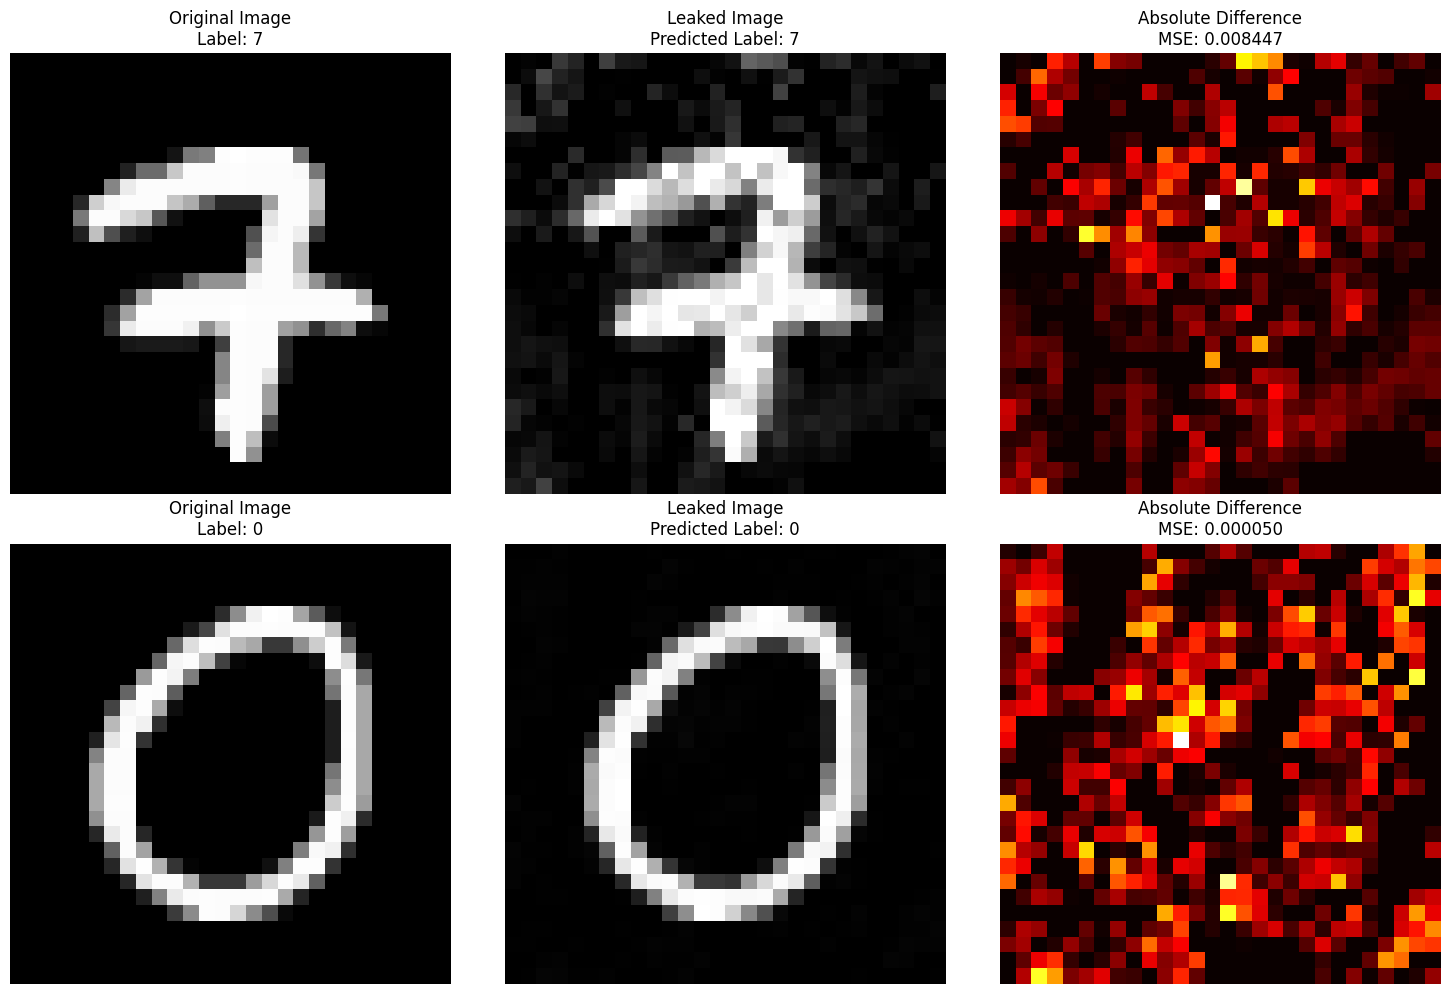

In [ ]:
#############################
# Run the ATTACK
#############################

def run_multiple_attacks(num_examples=2):
  print(f"\n{'='*60}")
  print(f"Running the DLG attack on {num_examples} private data")
  print(f"\n{'='*60}")

  model = LeNet().to(device)
  model.eval()

  results = []

  for i in range(num_examples):

    print(f"\n---Example {i+1}/{num_examples}")

    dataiter = iter(dataloader)
    original_data, original_label = next(dataiter)

    original_data = original_data.to(device)
    original_label = original_label.to(device)

    leaked_data, leaked_label, history = deep_leakage_from_gradients(
        model,
        original_data,
        original_label,
        num_iterations=100
    )

    leaked_pred = torch.argmax(F.softmax(leaked_label, dim =1), dim = 1).item()
    final_mse = history['mse'][-1]

    results.append({
        'original': original_data,
        'leaked': leaked_data,
        'original_label': original_label.item(),
        'leaked_label': leaked_pred,
    })

    print(f"Original label: {original_label }")
    print(f"Predicted label: {leaked_pred}")
    print(f"final msw: {final_mse}")

  plot_results(results)

run_multiple_attacks(num_examples=2)

# What Does It Mean When Loss and MSE Suddenly Increase in DLG?

In **DLG**, the interpretation of loss and MSE is very different from normal model training. Let’s break this down **conceptually, mathematically, and practically**.

---

## What “Loss” and “Gradient MSE” Mean in DLG

### In Standard Training
- Loss ↑ → model performance is getting worse  
- Loss ↓ → model is learning  

### In DLG (Important Difference)
DLG is **not training a model**.  
Instead, it solves a **gradient-matching optimization problem**.

The objective is:

Loss / Gradient MSE  
= how different the dummy gradients are from the true gradients

Lower value:
- Dummy data produces gradients similar to the real data

Higher value:
- Dummy data produces gradients very different from the real data

So in DLG:
- **Loss ↓ means reconstruction is improving**
- **Loss ↑ means reconstruction is failing**

---

## What Does a Sudden Increase Mean?

**Short answer:**  
The optimizer stepped into a region where gradient matching is impossible and cannot recover.

More precisely:
- The dummy input no longer corresponds to any real data sample
- The gradients become incompatible with the target gradients
- Optimization collapses

---

## Main Reasons Loss / MSE Suddenly Increases

### Reason 1: Optimizer Overshoot (Most Common)

Occurs especially with:
- L-BFGS optimizer  
- High learning rate  
- Highly non-convex objective (DLG is extremely non-convex)

What happens:
- Optimizer takes a large step
- Leaves the narrow “gradient-matching basin”
- Cannot find a path back

**Typical symptom:**
- Loss decreases initially  
- Sudden large jump  
- Then stagnates at a high value  

This behavior exactly matches what is often observed in DLG runs.

---

### Reason 2: Label Mismatch Collapse (DLG-Specific)

If dummy labels drift toward the wrong class:
- Cross-entropy gradients flip direction
- Gradient alignment becomes impossible

Effect:
- Gradients at the final layer become effectively orthogonal
- Gradient MSE spikes sharply

This failure mode is **unique to DLG**, not normal training.

---

### Reason 3: Numerical Instability

Common causes:
- Softmax + CrossEntropyLoss with near-zero probabilities  
- Exploding dummy pixel values  
- Large gradient magnitudes  

Effect:
- Gradients become unstable or NaN-like
- Loss either explodes or freezes

This is a silent but common failure in gradient inversion attacks.

---

### Reason 4: Ill-Posed Optimization

DLG optimization is:
- Over-constrained early
- Under-constrained after overshoot

Once the optimizer leaves the valid region:
- No descent direction exists
- Loss plateaus or increases permanently

---

## How to Interpret Sudden Increase (Key Insight)

It does **NOT** mean:
- The model is bad  
- The gradients are wrong  

It **DOES** mean:
- Optimization has failed  
- Dummy data no longer matches any real input  
- The attack failed for this run  

This is why DLG papers commonly:
- Restart with new initialization  
- Reduce learning rate  
- Change optimizer settings  

---

## hy This Happens More in DLG Than Normal Training

| Training | DLG |
|--------|-----|
| Optimize weights | Optimize inputs |
| Locally smooth | Highly non-convex |
| Many good minima | Extremely few valid minima |
| Stable | Very fragile |

DLG has **almost no tolerance for bad steps**.

---

## Visual Intuition (Very Important)

Think of gradient space as:

- True gradient = a tiny point  
- Valid reconstructions = tiny basin around it  
- Everywhere else = flat, useless plateau  

Once the optimizer jumps outside the basin:
- There is no gradient signal to return
- Loss jumps and freezes

---

## When Is an Increase NOT a Problem?

 Normal oscillation:
```
2.3 → 2.1 → 2.4 → 2.0
```

Attack failure:
```
3.1 → 15.7 → 15.7 → 15.7
```

A **sudden jump followed by stagnation** means the attack failed.

---

## Practical Rules for DLG (Standard Practice)

✔ Restart if loss spikes early  
✔ Restart if loss stagnates for >500 iterations  
✔ Always clamp dummy inputs  
✔ Use multiple random initializations  
✔ Log and inspect loss curves  

These practices are standard in DLG experiments and research code.

---

### Final Takeaway

In DLG:
- Sudden loss increase = **optimization failure**
- Not a bug, not a bad model
- Just the fragile nature of gradient inversion

This fragility is also what makes **defenses like noise and regularization effective**.


# 9. Defense Demonstrations

## Purpose
Demonstrates how privacy defenses can mitigate the DLG attack, focusing on **gradient noise addition**.

---

## How the Defense Works

### 1. Gradient Noise Addition
- Adds Gaussian noise to the original gradients  
- **Sigma (σ):** Controls the magnitude of the noise  
- **Concept:** Makes gradients less informative about individual training samples

### 2. Attack Against Noisy Gradients
- The DLG attack now attempts to match **noisy gradients** instead of clean gradients  
- This reduces the attack’s ability to accurately reconstruct the original data

### 3. Testing Different Noise Levels
The code experiments with 4 noise levels


**Expected Results:**  
- Small σ: Attack may still succeed  
- Moderate σ: Reconstruction becomes imperfect  
- High σ: Attack fails to recover usable private data  




Testing defenses...

Testing Defense: Gaussian Noise (σ=0.0001)



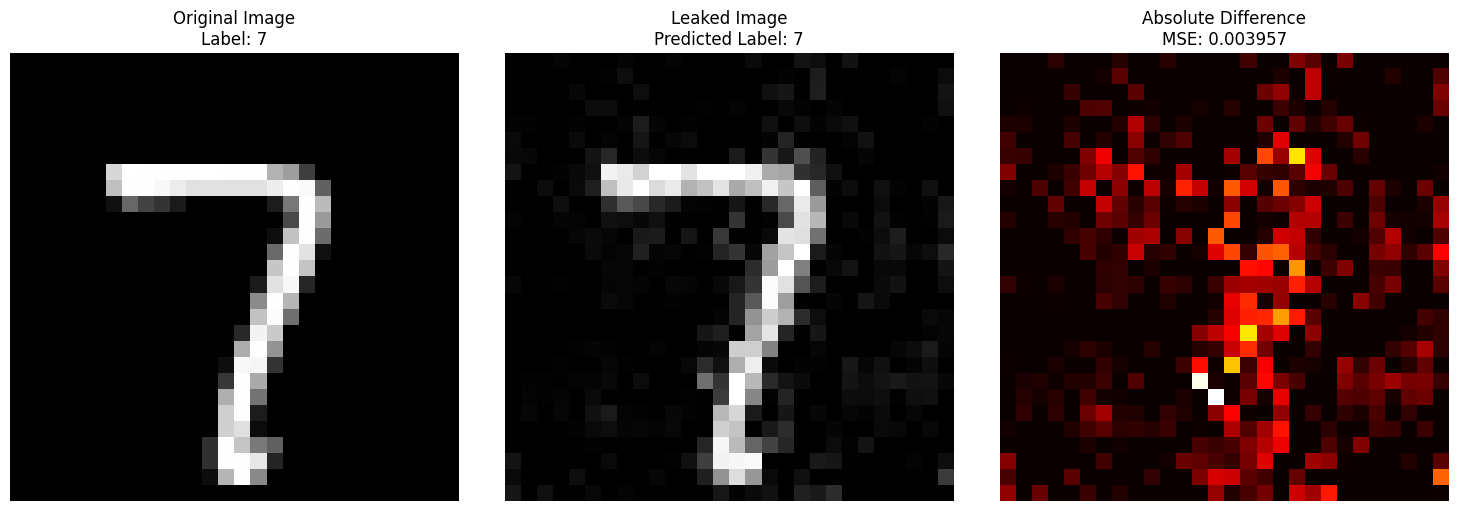

Defense Result: MSE = 4.904433
Defense FAILED

Testing Defense: Gaussian Noise (σ=0.001)



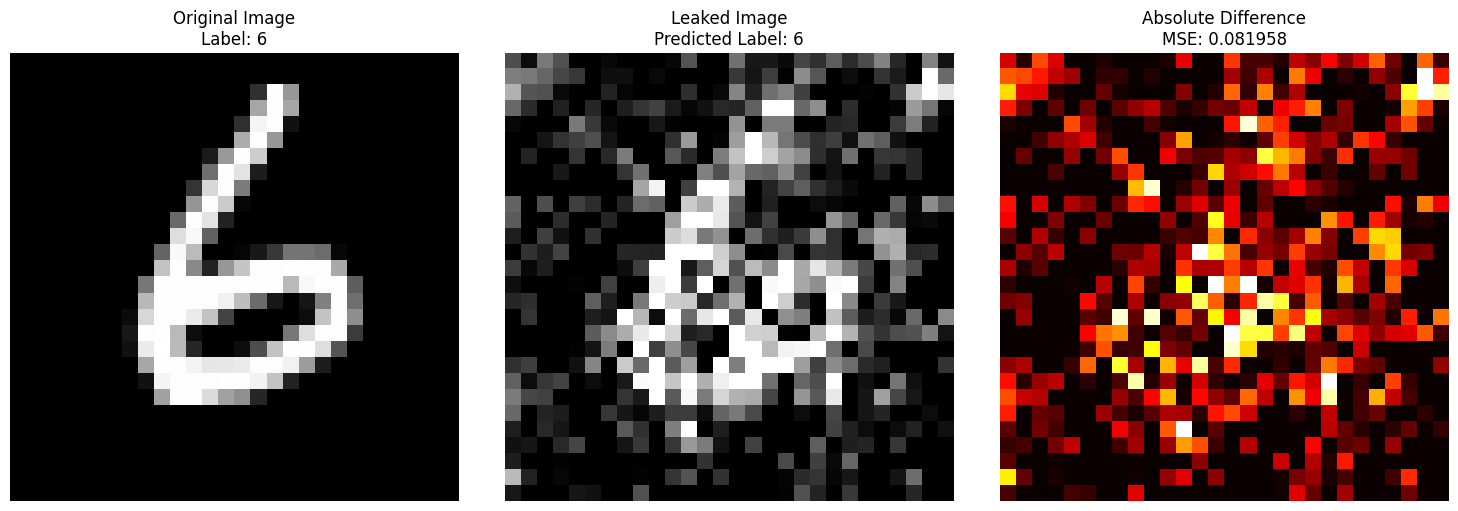

Defense Result: MSE = 117.528915
Defense SUCCESSFUL

Testing Defense: Gaussian Noise (σ=0.01)



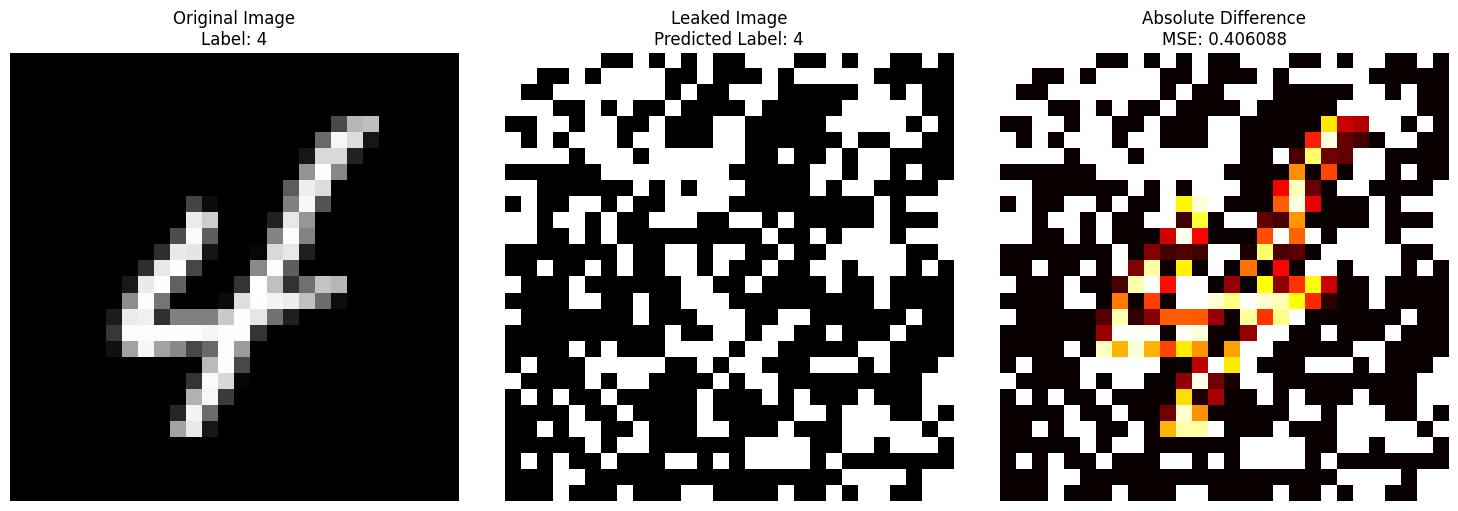

Defense Result: MSE = 2927447829905408.000000
Defense SUCCESSFUL

Testing Defense: Gaussian Noise (σ=0.1)



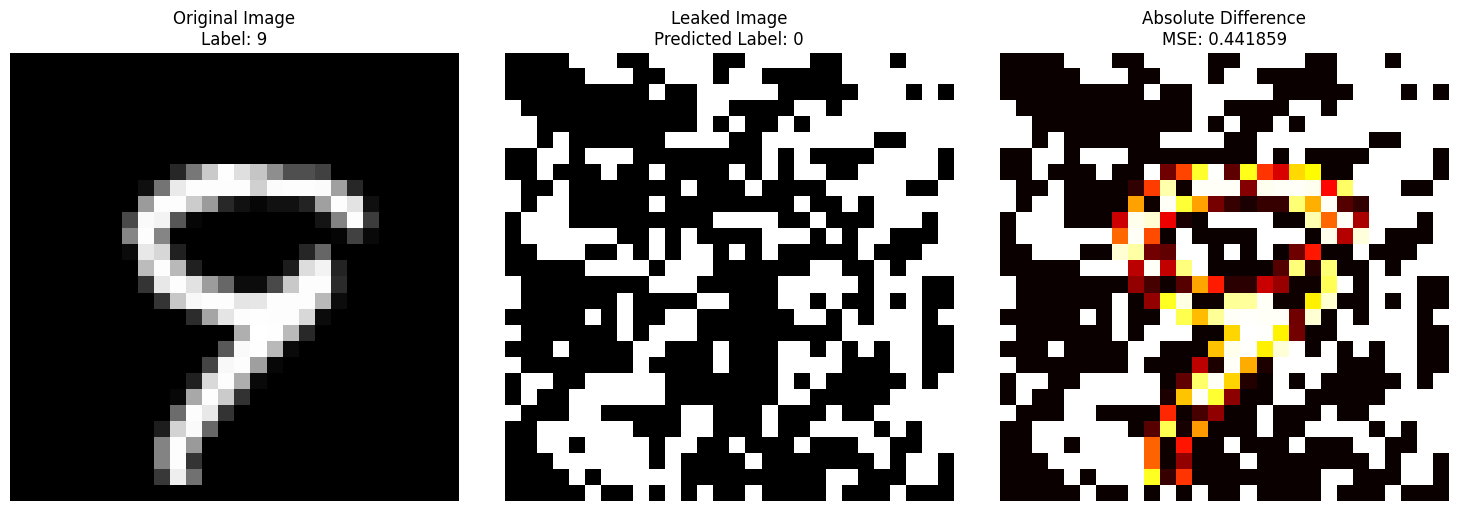

Defense Result: MSE = 775586737815552.000000
Defense SUCCESSFUL

✅ All experiments completed!


In [ ]:
#############################
# Defense Demonstrations
#############################

def test_defence_noise(sigma=0.001):
  model = LeNet().to(device)
  model.eval()
  dataiter = iter(dataloader)
  original_data, original_label = next(dataiter)

  original_data = original_data.to(device)
  original_label = original_label.to(device)

  model.zero_grad()

  original_pred = model(original_data)
  original_loss = F.cross_entropy(original_pred, original_label)
  original_gradients = torch.autograd.grad(original_loss, model.parameters(), create_graph=False)

  noisy_gradients = []

  for grad in original_gradients:
    noise = torch.randn_like(grad) * sigma
    noisy_gradients.append((grad + noise ).detach())

  dummy_data = torch.randn(original_data.size()).to(device).requires_grad_(True)
  dummy_label = torch.randn(original_data.shape[0], 10).to(device).requires_grad_(True)

  optimizer = torch.optim.Adam([dummy_data, dummy_label], lr=0.01)

  for iteration in range(100):
    # the following code might be wrong check with prof's completed code
    def closure():
      optimizer.zero_grad()
      dummy_label_softmax = F.softmax(dummy_label, dim=1)
      dummy_pred = model(dummy_data)
      dummy_loss = F.cross_entropy(dummy_pred, dummy_label_softmax)
      dummy_gradients = torch.autograd.grad(dummy_loss, model.parameters(), create_graph=True)

      grad_diff = 0
      for dummy_grad, original_grad in zip(dummy_gradients, original_gradients):
        grad_diff += ((dummy_grad - original_grad) ** 2).sum()

      grad_diff.backward()
      return grad_diff

    loss = optimizer.step(closure)
    results = []
    results.append({
        'original': original_data,
        'leaked': dummy_data,
        'original_label': original_label.item(),
        'leaked_label': torch.argmax(dummy_label, dim=1).item(),
    })


# Test different noise levels
print("\n\nTesting defenses...")
test_defense_noise(sigma=0.0001)
test_defense_noise(sigma=0.001)
test_defense_noise(sigma=0.01)
test_defense_noise(sigma=0.1)

print("\nAll experiments completed!")